
## 1. Configuración Inicial

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Agregar ruta de src al path
sys.path.insert(0, r'C:\Users\Arturo\Desktop\Prueba1\src')

# Importar módulos personalizados
from prueba.data_preprocessing import cargar_datos_crudos, limpiar_datos_basico, crear_features_empleado

# Configuración de estética y reproducibilidad
sns.set_theme(style="whitegrid")
seed = 42 
np.random.seed(seed)

# Configurar path para cargar desde la raiz del proyecto (ruta absoluta)
project_root = r'C:\Users\Arturo\Desktop\Prueba1'

# Cargar datos crudos
print("Cargando datos crudos...")
datos_crudos = cargar_datos_crudos(os.path.join(project_root, 'data/01_raw/'))

print("\nDatos cargados:")
for nombre, df_temp in datos_crudos.items():
    print(f"  - {nombre}: {df_temp.shape}")

# Crear dataset consolidado con features de empleados
print("\nCreando dataset consolidado con features...")
df = crear_features_empleado(datos_crudos)

print(f"\nDataset consolidado: {df.shape}")
print(f"Columnas: {list(df.columns)}")

Cargando datos crudos...
  Cargado: ausencias (360 filas, 7 columnas)
  Cargado: capacitaciones (412 filas, 8 columnas)
  Cargado: empleados (309 filas, 9 columnas)
  Cargado: evaluaciones (515 filas, 7 columnas)

Datos cargados:
  - ausencias: (360, 7)
  - capacitaciones: (412, 8)
  - empleados: (309, 9)
  - evaluaciones: (515, 7)

Creando dataset consolidado con features...

Dataset consolidado: (309, 16)
Columnas: ['id_empleado', 'departamento', 'cargo', 'tipo_contrato', 'jornada', 'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia', 'ausencias_justificadas', 'num_capacitaciones', 'total_horas_capacitacion', 'promedio_nota_capacitacion', 'max_nota_capacitacion', 'puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas']


2. Inspección de Calidad de Datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_empleado                 309 non-null    float64
 1   departamento                309 non-null    object 
 2   cargo                       309 non-null    object 
 3   tipo_contrato               309 non-null    object 
 4   jornada                     309 non-null    object 
 5   total_dias_ausencia         309 non-null    float64
 6   promedio_dias_ausencia      309 non-null    float64
 7   max_dias_ausencia           309 non-null    float64
 8   ausencias_justificadas      309 non-null    float64
 9   num_capacitaciones          309 non-null    float64
 10  total_horas_capacitacion    309 non-null    float64
 11  promedio_nota_capacitacion  309 non-null    float64
 12  max_nota_capacitacion       309 non-null    float64
 13  puntaje_desempeno           309 non

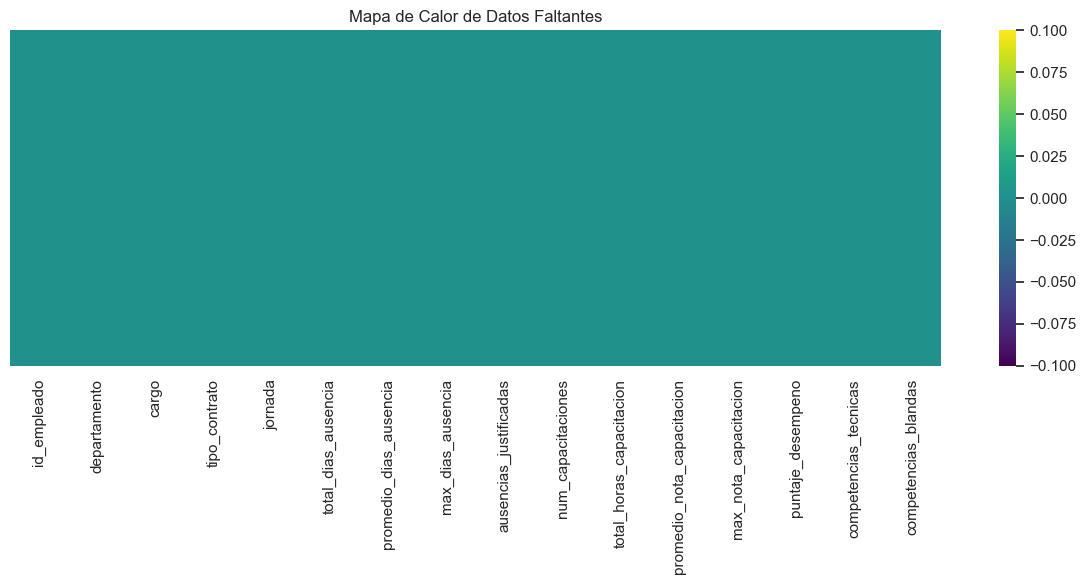


Estadísticas Descriptivas:
       id_empleado  total_dias_ausencia  promedio_dias_ausencia  \
count   309.000000           309.000000              309.000000   
mean    148.432039            17.359223                9.555353   
std      84.534210            23.809384                9.004346   
min       1.000000             0.000000                0.000000   
25%      78.000000             0.000000                0.000000   
50%     146.500000            12.000000                9.000000   
75%     219.000000            26.000000               16.600000   
max     300.000000           243.000000               29.000000   

       max_dias_ausencia  ausencias_justificadas  num_capacitaciones  \
count         309.000000                   309.0          309.000000   
mean           11.278317                     0.0            1.310680   
std            10.544289                     0.0            1.724701   
min             0.000000                     0.0            0.000000   
25%     

In [20]:
# Verificación de tipos y nulos
print(df.info())

# Visualización de datos faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title("Mapa de Calor de Datos Faltantes")
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/01_datos_faltantes.png'), dpi=300, bbox_inches='tight')
plt.show()

# Estadísticas descriptivas
print("\nEstadísticas Descriptivas:")
print(df.describe())

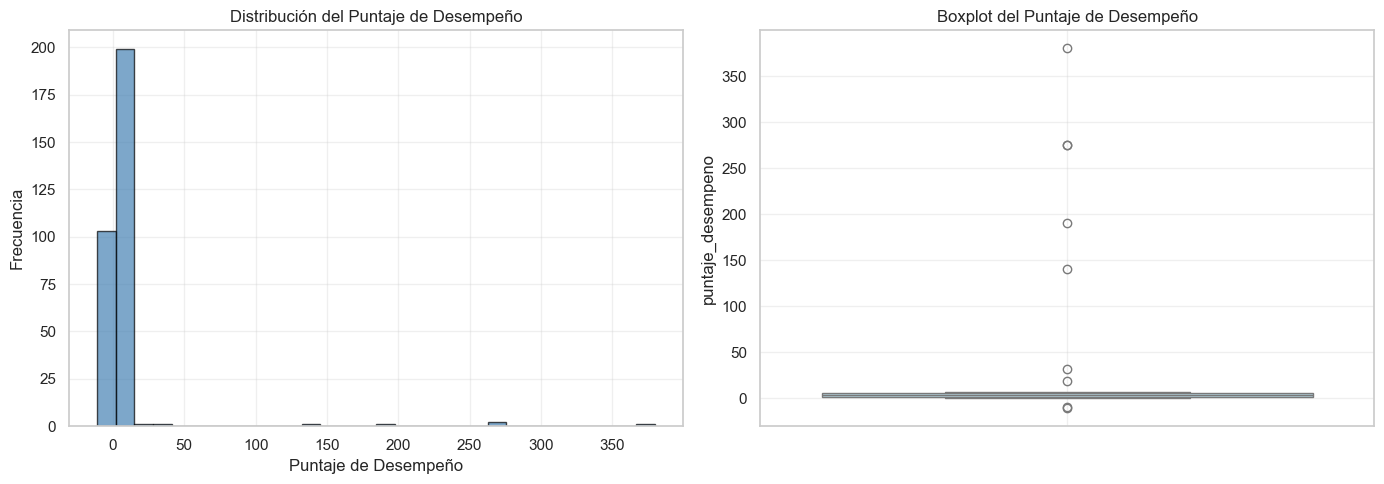


Estadísticas de Puntaje de Desempeño:
count    309.000000
mean       7.373139
std       33.269117
min      -11.000000
25%        1.300000
50%        3.800000
75%        5.300000
max      380.000000
Name: puntaje_desempeno, dtype: float64


In [21]:
# Distribución de la variable objetivo (Puntaje de Desempeño)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['puntaje_desempeno'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Puntaje de Desempeño')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Puntaje de Desempeño')
axes[0].grid(alpha=0.3)

sns.boxplot(data=df, y='puntaje_desempeno', ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot del Puntaje de Desempeño')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/02_distribucion_target.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nEstadísticas de Puntaje de Desempeño:")
print(df['puntaje_desempeno'].describe())

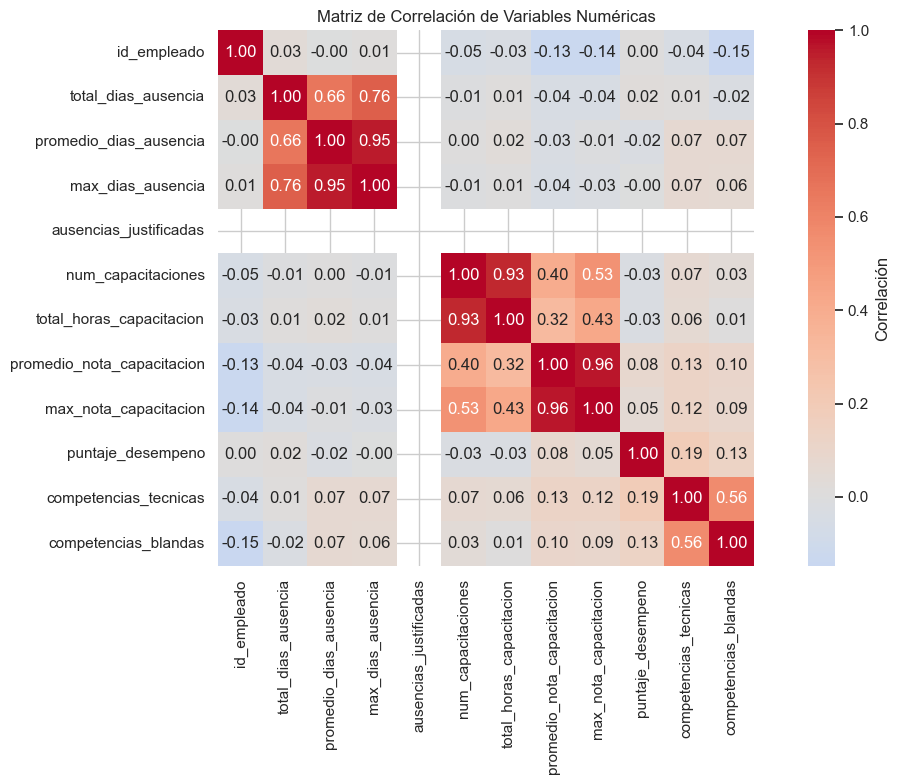


Correlaciones con Puntaje de Desempeño (Ordenadas):
puntaje_desempeno             1.000000
competencias_tecnicas         0.188786
competencias_blandas          0.127811
promedio_nota_capacitacion    0.081814
max_nota_capacitacion         0.052984
total_dias_ausencia           0.021645
id_empleado                   0.000471
max_dias_ausencia            -0.000726
promedio_dias_ausencia       -0.024662
total_horas_capacitacion     -0.025086
num_capacitaciones           -0.029108
ausencias_justificadas             NaN
Name: puntaje_desempeno, dtype: float64


In [22]:
# Matriz de correlación
plt.figure(figsize=(12, 8))
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[cols_numericas].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlación'}, square=True)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_correlaciones.png'), dpi=300, bbox_inches='tight')
plt.show()

# Correlaciones con el target
print("\nCorrelaciones con Puntaje de Desempeño (Ordenadas):")
corr_target = corr_matrix['puntaje_desempeno'].sort_values(ascending=False)
print(corr_target)

In [23]:
print("="*70)
print("RESUMEN DEL ANALISIS EXPLORATORIO")
print("="*70)

print(f"\n1. DIMENSIONALIDAD DE DATOS:")
print(f"   - Total de registros (empleados): {df.shape[0]}")
print(f"   - Total de features: {df.shape[1]}")
print(f"   - Features numéricas: {len(df.select_dtypes(include=['float64', 'int64']).columns)}")
print(f"   - Features categóricas: {len(df.select_dtypes(include=['object']).columns)}")

print(f"\n2. CALIDAD DE DATOS:")
total_nulos = df.isnull().sum().sum()
total_celdas = df.shape[0] * df.shape[1]
porcentaje_nulos = (total_nulos / total_celdas) * 100
print(f"   - Total valores faltantes: {total_nulos} ({porcentaje_nulos:.2f}%)")
print(f"   - Variables sin valores faltantes: {(df.isnull().sum() == 0).sum()}")

print(f"\n3. VARIABLE OBJETIVO (puntaje_desempeno):")
y = df['puntaje_desempeno'].dropna()
print(f"   - Muestras válidas: {len(y)}")
print(f"   - Media: {y.mean():.2f}")
print(f"   - Desv. Est.: {y.std():.2f}")
print(f"   - Min: {y.min():.2f}, Max: {y.max():.2f}")
print(f"   - Rango: {y.max() - y.min():.2f}")

print(f"\n4. FEATURES MÁS CORRELACIONADOS CON TARGET:")
corr_target = corr_matrix['puntaje_desempeno'].drop('puntaje_desempeno').sort_values(ascending=False)
for i, (feature, corr) in enumerate(corr_target.head(5).items(), 1):
    print(f"   {i}. {feature}: {corr:.3f}")

print("\n" + "="*70)

RESUMEN DEL ANALISIS EXPLORATORIO

1. DIMENSIONALIDAD DE DATOS:
   - Total de registros (empleados): 309
   - Total de features: 16
   - Features numéricas: 12
   - Features categóricas: 4

2. CALIDAD DE DATOS:
   - Total valores faltantes: 0 (0.00%)
   - Variables sin valores faltantes: 16

3. VARIABLE OBJETIVO (puntaje_desempeno):
   - Muestras válidas: 309
   - Media: 7.37
   - Desv. Est.: 33.27
   - Min: -11.00, Max: 380.00
   - Rango: 391.00

4. FEATURES MÁS CORRELACIONADOS CON TARGET:
   1. competencias_tecnicas: 0.189
   2. competencias_blandas: 0.128
   3. promedio_nota_capacitacion: 0.082
   4. max_nota_capacitacion: 0.053
   5. total_dias_ausencia: 0.022



5. Resumen de Hallazgos del Análisis Exploratorio

4. Análisis de Correlaciones

3. Análisis Univariado y Distribuciones